# Workers Analysis

Analyse worker statistics from MCR experiment checkpoints.

Each checkpoint directory contains `redis_backup_db10.json` (LOGS) with per-iteration
worker events.  This notebook loads that data and produces summary tables and plots.

In [1]:
from pathlib import Path
from etl.loader import etl_from_dir, list_checkpoints

RESULTS_DIR = Path("results")

# List available checkpoints and pick one
checkpoints = list_checkpoints(RESULTS_DIR)
print(f"Found {len(checkpoints)} checkpoints:")
for i, cp in enumerate(checkpoints):
    print(f"  [{i}] {cp.relative_to(RESULTS_DIR)}")

# Select checkpoint (edit index or set CHECKPOINT_DIR directly)
CHECKPOINT_DIR = checkpoints[0] if checkpoints else None
print(f"\nUsing: {CHECKPOINT_DIR}")

Found 157 checkpoints:
  [0] checkpoints/amyloid_pos_vs_neg_fs3_fold1/workers_6/class_1
  [1] res_ablation/ann-thyroid/workers_16/class_1.0/ablation_R0_NR0_GP1_BP1
  [2] res_ablation/ann-thyroid/workers_16/class_1.0/ablation_R0_NR1_GP1_BP1
  [3] res_ablation/ann-thyroid/workers_16/class_1.0/ablation_R1_NR0_GP1_BP1
  [4] res_ablation/ann-thyroid/workers_16/class_1.0/ablation_R1_NR1_GP0_BP1
  [5] res_ablation/ann-thyroid/workers_16/class_1.0/ablation_R1_NR1_GP1_BP0
  [6] res_ablation/ann-thyroid/workers_16/class_1.0/all_features
  [7] res_ablation/ann-thyroid/workers_16/class_2.0/ablation_R0_NR1_GP1_BP1
  [8] res_ablation/ann-thyroid/workers_16/class_2.0/ablation_R1_NR0_GP1_BP1
  [9] res_ablation/ann-thyroid/workers_16/class_2.0/ablation_R1_NR1_GP0_BP1
  [10] res_ablation/ann-thyroid/workers_16/class_2.0/ablation_R1_NR1_GP1_BP0
  [11] res_ablation/ann-thyroid/workers_16/class_2.0/all_features
  [12] res_ablation/ann-thyroid/workers_16/class_3.0/ablation_R0_NR1_GP1_BP1
  [13] res_ablation

In [2]:
# Load checkpoint into structured db dict
db = etl_from_dir(CHECKPOINT_DIR, verbose=True)

Loading checkpoint: results/checkpoints/amyloid_pos_vs_neg_fs3_fold1/workers_6/class_1
Dataset: amyloid_pos_vs_neg_fs3_fold1
  DB00 (data): 66 keys
  DB01 (candidates): 0 keys
  DB02 (reasons): 18 keys
  DB03 (non_reasons): 135 keys
  DB04 (candidate_anti_reasons): 1164 keys
  DB05 (anti_reasons): 68 keys
  DB06 (good_profiles): 18 keys
  DB07 (bad_profiles): 135 keys
  DB08 (preferred_reasons): 20 keys
  DB09 (anti_reason_profiles): 68 keys


  DB10 (workers_report): 4042 keys
Loaded 11 databases.


In [3]:
from etl.logs_loader import build_db10_worker_report
from etl.constants import DB_NAMES
import json
from pathlib import Path

# Build worker report from DB10 entries stored in the db dict
# The logs_loader expects the old ZIP-based signature; we adapt here by
# reconstructing the minimal structures it needs from the directory.

checkpoint_dir = Path(db['_checkpoint_dir'])
db10_path = checkpoint_dir / 'redis_backup_db10.json'
manifest_path = checkpoint_dir / 'manifest.json'

manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else {}
db10_data = json.loads(db10_path.read_text()) if db10_path.exists() else {'entries': []}

# files_map for compatibility: map '10' -> filename
files_map = manifest.get('files', {})
if '10' not in files_map:
    files_map['10'] = 'redis_backup_db10.json'

mock_manifest = {'files': files_map}
mock_backups = {'redis_backup_db10.json': db10_data}
mock_archive_data = {'zip_path': str(checkpoint_dir)}
mock_prefix = ''

report = build_db10_worker_report(
    selected_zip_name=checkpoint_dir.name,
    selected_manifest=mock_manifest,
    selected_backups=mock_backups,
    selected_archive_data=mock_archive_data,
    selected_manifest_prefix=mock_prefix,
    max_events=None
)

# Store report in db for render_worker_report compatibility
db[DB_NAMES.get(10)] = report
print(f"Worker report built: {report.get('worker_count', 0)} workers")

Report built for 7 workers.
Worker report built: 7 workers


Detailed results per worker:
Plot 'Queue size vs iteration range' skipped: insufficient data.
Plot 'Candidate anti-reasons queue vs queue size' skipped: insufficient data.
Plot 'Candidate anti-reasons results per worker' skipped: no columns with prefix 'car_result_'.
Plot 'Candidate reasons results per worker' skipped: no columns with prefix 'can_result_'.
Plot 'Outcome flags per worker' skipped: no columns with prefix 'outcome_'.
Histogram 'Distribution of average queue size' skipped: insufficient data.
Plot 'Queue size overview' skipped: insufficient data.
Plot 'Candidate anti-reasons queue overview' skipped: insufficient data.
Worker iterations: 4042 rows across 7 workers.


,Worker,Records,Iteration min,Iteration max,Queue min,Queue mean,Queue max,Candidate anti-reasons queue min,Candidate anti-reasons queue mean,Candidate anti-reasons queue max,Total hours,Candidate anti-reasons hours,Candidate reasons hours
0,W01,662,0,661,None,None,None,None,None,None,0.0,0.0,0.0
1,W02,663,0,662,None,None,None,None,None,None,0.0,0.0,0.0
2,W03,507,0,506,None,None,None,None,None,None,0.0,0.0,0.0
3,W04,718,0,717,None,None,None,None,None,None,0.0,0.0,0.0
4,W05,833,0,832,None,None,None,None,None,None,0.0,0.0,0.0
5,W06,619,0,618,None,None,None,None,None,None,0.0,0.0,0.0
6,W07,40,1780,1819,None,None,None,None,None,None,0.0,0.0,0.0


,Worker
0,W01
1,W02
2,W03
3,W04
4,W05
5,W06
6,W07


,Worker,Event order,Iteration,Start time,End time,Queue Size,Candidate anti-reasons queue size,Total seconds,Candidate anti-reasons seconds,Candidate reasons seconds,Candidate anti-reasons result,Candidate reasons result,Outcomes
0,W01,1,0,NaT,NaT,None,None,None,None,None,None,None,None
1,W01,2,1,NaT,NaT,None,None,None,None,None,None,None,None
2,W01,3,2,NaT,NaT,None,None,None,None,None,None,None,None
3,W01,4,3,NaT,NaT,None,None,None,None,None,None,None,None
4,W01,5,4,NaT,NaT,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4037,W07,36,1815,NaT,NaT,None,None,None,None,None,None,None,None
4038,W07,37,1816,NaT,NaT,None,None,None,None,None,None,None,None
4039,W07,38,1817,NaT,NaT,None,None,None,None,None,None,None,None
4040,W07,39,1818,NaT,NaT,None,None,None,None,None,None,None,None


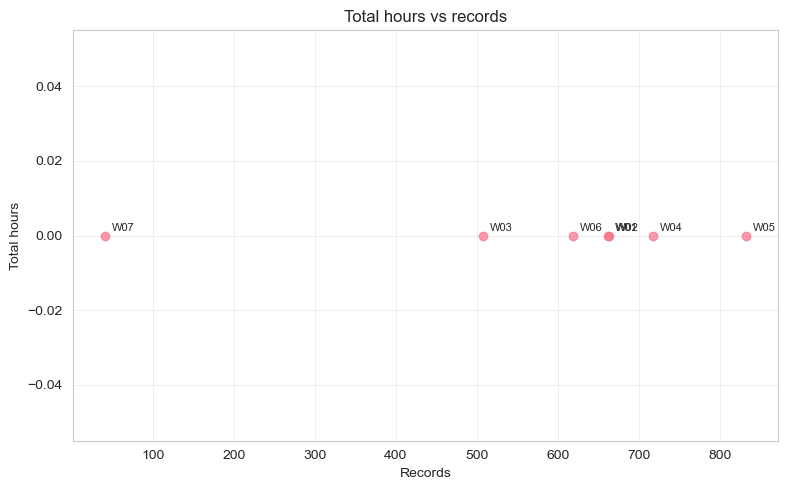

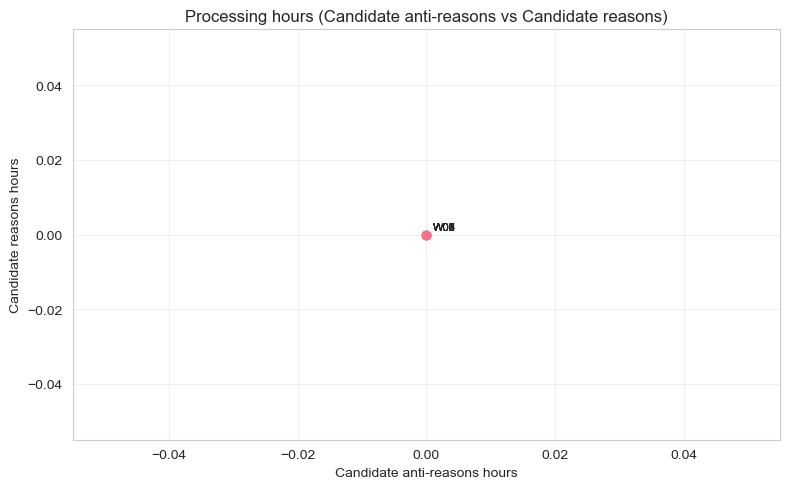

<Figure size 800x500 with 0 Axes>

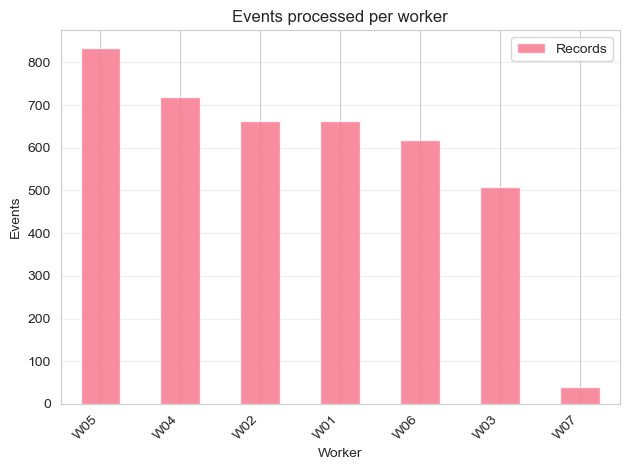

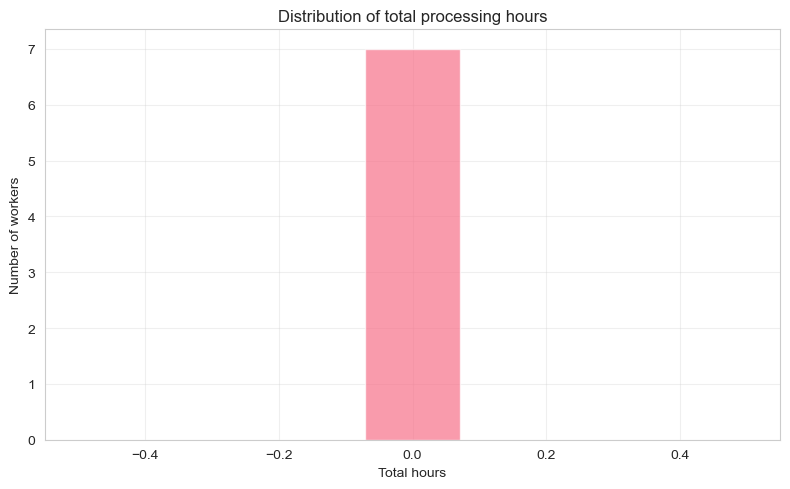

In [4]:
from etl.logs_loader import render_worker_report

workers_table, workers_table2, workers_table3, plots = render_worker_report(db)
display(workers_table)
display(workers_table2)
display(workers_table3)